In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
from scipy.stats import zscore
import os
import gzip
import re

# Filter Multiplexing Genes from Data

The data has multiplexing genes starting wuth HTO or TSB0. These multiplexing genes need to be filtered out. 

In [10]:
# Filter out multiplexing genes
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/adata.combined.h5ad')

# Genes to be filtered out
genes_to_exclude = ['TSB0251', 'TSB0252', 'TSB0253', 'HTO-1', 'HTO-2', 'HTO-3']

# Filter out specified genes
filtered_adata = adata[:, ~adata.var_names.isin(genes_to_exclude)]

# Print or use the filtered adata object
filtered_adata

View of AnnData object with n_obs × n_vars = 61925 × 32485
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Sample'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    obsm: 'gene_expression_encoding'

In [5]:
'''
This makes sense. 
The filtered adata has size: 61925 × 32485. 
The original adata has size: 61925 × 32491. 
We can assume the adata has been properly filtered. 
'''
adata

AnnData object with n_obs × n_vars = 61925 × 32491
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Sample'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    obsm: 'gene_expression_encoding'

In [8]:
# Save the filtered adata without multiplexing
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/'
os.makedirs(out_dir,exist_ok=True)

filtered_adata.write_h5ad(out_dir + 'adata.combined.filtered.h5ad')
filtered_adata.obs.to_csv(out_dir + 'obs.combined.filtered.csv', sep ='\t')

# Perform HVG, PCA, Clustering, and UMAP Visualization on Filtered Data

In [27]:
# Read in the filtered adata
adata = sc.read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_concat/adata.combined.filtered.h5ad")

In [28]:
adata

AnnData object with n_obs × n_vars = 61925 × 32485
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Sample'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells'
    obsm: 'gene_expression_encoding'

In [14]:
bad_genes = ['TSB0251', 'TSB0252', 'TSB0253', 'HTO-1', 'HTO-2', 'HTO-3']

ref_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/scripts/organoid_analysis_pipeline_scripts/'
sample_df = pd.read_csv(ref_dir + 'Organoid_Sample_Description.txt', sep='\t',index_col=0)

mtx_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' +  'scran_output_matrix.mtx'
g_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' + 'scran_genes.csv'
bc_fn = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_scran/' + 'scran_barcodes.csv'

fn = g_fn
with open(fn, 'r') as f:
    g = [i.strip() for i in f.readlines()]

fn = bc_fn
with open(fn, 'r') as f:
    bc = [i.strip() for i in f.readlines()]

from scipy.io import mmread
norm_df = mmread(mtx_fn)
norm_df = norm_df.tocsr().toarray()
norm_df = pd.DataFrame(norm_df, index=bc, columns=g)

norm_df = norm_df.loc[:, ~norm_df.columns.isin(bad_genes)]

samples = [re.sub('_[ACGT]+-1$','',i) for i in bc]
samples = pd.Series(samples, index = bc)

bc_intersect = adata.obs.index.intersection(norm_df.index)
g_intersect = adata.var_names.intersection(norm_df.columns)
adata = adata[bc_intersect, g_intersect]
adata.layers["counts"] = adata.X.copy()
norm_df = norm_df.loc[adata.obs.index, adata.var_names]

adata.X = norm_df.values
adata.layers['without_log'] = adata.X

adata.raw = adata  # Save the raw data before log transformation
sc.pp.log1p(adata, base=2)

sample_df2 = sample_df.loc[samples,:]
sample_df2.index = adata.obs.index

adata.obs = pd.concat([adata.obs.drop('Sample', axis=1), sample_df2], axis=1)

adata.obs['Sample'] = adata.obs['Sample'].astype('category')

/scratch/lsftmp/2602709.tmpdir/ipykernel_87150/1305479758.py:31: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


In [15]:
'''
Highly Variable Genes
'''
adata.obs['Batch'] = adata.obs.Batch.astype(str).astype('category')

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=5000,
    layer="counts",
    flavor="seurat_v3",  # Change to "seurat"
    batch_key="Batch"
)

norm_df = pd.DataFrame(adata.X, index=adata.obs_names, columns = adata.var_names)
norm_df = norm_df.loc[:,adata.var.highly_variable]

bad_genes = norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
norm_df = norm_df.loc[:,~bad_genes]

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)

    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [17]:
'''
PCA
'''
print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))

var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata.obsm['X_pca'] = pca_merge.loc[adata.obs_names,:].values
adata.uns['num_components'] = num_components
adata.uns['var_explained'] = var_explained

Performing PCA
# Components = 50
Variance explained = 0.345686


In [18]:
'''
NEAREST NEIGHBORS
'''
print('Performing nearest neighbors')
n_neighbors=30
min_dist = 0.3
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=pca_merge.shape[1])

Performing nearest neighbors


In [19]:
'''
CLUSTERING
'''
print('Phenograph Clustering')
import phenograph
clusters_merge, _, _ = phenograph.cluster(pca_merge, k=30)
clusters_merge = pd.Series(clusters_merge, pca_merge.index)

adata.obs['phenograph'] = clusters_merge.loc[adata.obs_names].astype('str').astype('category')

Phenograph Clustering
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 3.8081002235412598 seconds
Jaccard graph constructed in 13.842390537261963 seconds
Wrote graph to binary file in 0.6744458675384521 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.926541
After 5 runs, maximum modularity is Q = 0.927646
Louvain completed 25 runs in 39.12888979911804 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 61.91252613067627 seconds


In [20]:
'''
UMAP
'''
print('Performing UMAP')
sc.tl.paga(adata, groups = 'phenograph')
sc.pl.paga(adata, plot=False)
sc.tl.umap(adata, init_pos='paga', min_dist=min_dist)

Performing UMAP


In [23]:
# Save the combined, filtered, post-processed data
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/'
os.makedirs(out_dir,exist_ok=True)

filtered_adata.write_h5ad(out_dir + 'adata.combined.filtered.hvg_5000.h5ad')
filtered_adata.obs.to_csv(out_dir + 'obs.combined.filtered.hvg_5000.csv', sep ='\t')

# Perform UMAP Visualization on Filtered, Processed Data

In [2]:
adata = sc.read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.filteredmultiplex.combined.hvg_5000.h5ad")

In [32]:
adata.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,log10_original_total_counts,mito_frac,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Replicate,Batch,Sample,phenograph
146P_BASE_shZFP36L2_3_TTAGGGTCAGTAACGG-1,0.028566,0.999801,8876.052734,1.340430,3138,8.051660,9862,9.196546,29.132022,40.701683,...,3.993965,0.048874,146,Primary,BASE,ZFP_KD,1,5,146_P_BASE_ZFPKD_1,5
KG146Li_BASE_shZFP36L2_4_CGTTAGACACGTAACT-1,0.116489,0.999945,9333.853516,0.757079,1427,7.264030,5294,8.574518,68.530412,71.269362,...,3.723784,0.373064,146,Metastatic,BASE,ZFP_KD,2,2,146_M_BASE_ZFPKD_2,14
146P_BASE_shCTRL_AGGTGTTCATACAGGG-1,0.075099,1.000000,8071.062012,0.780837,2078,7.639642,4914,8.500047,35.978836,44.342694,...,3.691435,0.087098,146,Primary,BASE,CTRL,1,5,146_P_BASE_CTRL_1,0
146P_BASE_shZFP36L2_4_CCTCTAGGTCGCATTA-1,0.015017,0.999890,10491.471680,1.244276,4046,8.305731,11282,9.331052,21.680553,30.269456,...,4.052386,0.042723,146,Primary,BASE,ZFP_KD,2,5,146_P_BASE_ZFPKD_2,0
125P_HISC_shZFP36L2_3_GTTGTCCTCCACTGGG-1,0.023782,0.999968,12623.271484,1.163859,3437,8.142645,12520,9.435163,43.170927,51.829073,...,4.097604,0.066134,125,Primary,HISC,ZFP_KD,1,1,125_P_HISC_ZFPKD_1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125P_HISC_shZFP36L2_4_TTCGGTCTCCGTTGGG-1,0.032047,0.999999,11612.512695,1.116061,3433,8.141481,10813,9.288597,33.764913,44.696199,...,4.033946,0.053824,125,Primary,HISC,ZFP_KD,2,1,125_P_HISC_ZFPKD_2,3
146P_HISC_shZFP36L2_4_ACAAAGATCATCACTT-1,0.021406,0.999804,12408.628906,1.137434,4342,8.376321,11932,9.387063,30.263158,36.188401,...,4.076713,0.100067,146,Primary,HISC,ZFP_KD,2,6,146_P_HISC_ZFPKD_2,13
146P_BASE_shZFP36L2_3_TCAGGTAAGTTTAGGA-1,0.030128,0.999998,8865.494141,1.121671,2957,7.992269,8241,9.016998,31.707317,41.730373,...,3.915980,0.036403,146,Primary,BASE,ZFP_KD,1,5,146_P_BASE_ZFPKD_1,0
146P_HISC_shZFP36L2_3_TCATCATAGATCGGTG-1,0.018190,0.999955,13321.495117,1.290548,4366,8.381832,14735,9.598049,30.580251,40.190024,...,4.168350,0.047506,146,Primary,HISC,ZFP_KD,1,6,146_P_HISC_ZFPKD_1,1


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

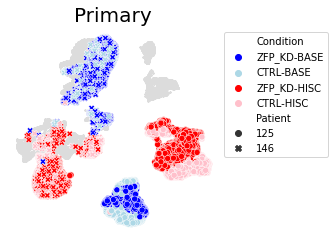

In [4]:
# UMAP for conditions in primary tumor site
color_labels = {}
for col, j in zip(['blue','red','orange'],['BASE','HISC','Dedifferentiated']):
    for shade,i in zip(['light',''],['CTRL','ZFP_KD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
        if color_labels[i + '-' + j] =='darkred':
            color_labels[i + '-' + j] = 'orange'
        if color_labels[i + '-' + j] =='lightorange':
            color_labels[i + '-' + j] = 'moccasin'


fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

ind1 = adata.obs.Tumor_Site=='Primary'
ind2 = adata.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

plt.scatter(plot_df.loc[~ind,'x'], plot_df.loc[~ind,'y'], color='gainsboro', s=3, marker='x')

sns.scatterplot(data=plot_df.loc[ind,:], x='x',y='y', style='Patient', hue='Condition',
                    markers = {125: 'o', 146: 'X'},
                    palette = color_labels, ax=ax)


ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


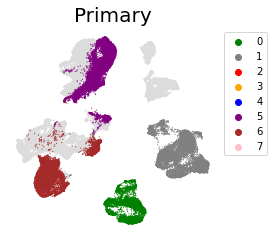

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.8))

ind1 = adata.obs.Tumor_Site == 'Primary'
ind2 = adata.obs.Culture_Media != 'Dedifferentiated'
ind = ind1.values & ind2.values

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:, ['Patient', 'Culture_Media', 'ZFP_Expression', 'Batch']]
plot_df['x'] = umap[:, 0].tolist()
plot_df['y'] = umap[:, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

plt.scatter(plot_df.loc[~ind, 'x'], plot_df.loc[~ind, 'y'], color='gainsboro', s=1, marker='x')

g = sns.scatterplot(data=plot_df.loc[ind, :], x='x', y='y', hue='Batch',
                    s=1, edgecolor=None,
                    palette={'0': 'green', '1': 'grey', '2': 'red', '3': 'orange', '4': 'blue', '5': 'purple', '6': 'brown', '7': 'pink'},
                    ax=ax)

ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('Primary', fontsize=20)

plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Metastasis in Patient 146')

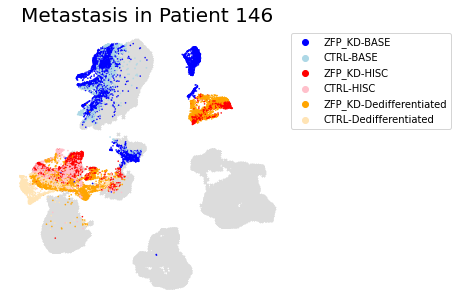

In [5]:
# UMAP for conditions in the metastatic tumor site
fig, ax=plt.subplots(1,1, figsize=(5,5))

ind = adata.obs.Tumor_Site=='Metastatic'

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

plt.scatter(plot_df.loc[~ind,'x'], plot_df.loc[~ind,'y'], color='gainsboro', s=10, marker='x')

g = sns.scatterplot(data=plot_df.loc[ind,:], x='x',y='y', hue='Condition',
                    s=2,edgecolor=None,
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Metastasis in Patient 146',fontsize=20)

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


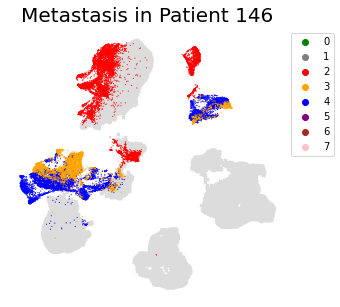

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ind = adata.obs.Tumor_Site == 'Metastatic'

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:, ['Patient', 'Culture_Media', 'ZFP_Expression', 'Batch']]
plot_df['x'] = umap[:, 0].tolist()
plot_df['y'] = umap[:, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

plt.scatter(plot_df.loc[~ind, 'x'], plot_df.loc[~ind, 'y'], color='gainsboro', s=10, marker='x')

g = sns.scatterplot(data=plot_df.loc[ind, :], x='x', y='y', hue='Batch',
                    s=1, edgecolor=None,
                    palette={'0': 'green', '1': 'grey', '2': 'red', '3': 'orange', '4': 'blue', '5': 'purple', '6': 'brown', '7': 'pink'},
                    ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('Metastasis in Patient 146', fontsize=20)

plt.show()


# Subset Patient 125 Data

In [4]:
# Read in the filtered, combined adata
adata = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.filteredmultiplex.combined.hvg_5000.h5ad')
adata

AnnData object with n_obs × n_vars = 59140 × 32485
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'log10GenesPerUMI', 'original_total_counts', 'log10_original_total_counts', 'mito_frac', 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Replicate', 'Batch', 'Sample', 'phenograph'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ribo', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'umap', 'var_explained'
    obsm: 'X_pca', 'X_umap', 'gene_expression_encoding'
    layers: 'counts', 'without_log'
 

In [5]:
# Filter the data for Patient 125
adata_125 = adata[adata.obs['Patient'] == 125].copy()

In [6]:
# Check that the Patient 125 data is correct
adata_125.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,log10_original_total_counts,mito_frac,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Replicate,Batch,Sample,phenograph
125P_HISC_shZFP36L2_3_GTTGTCCTCCACTGGG-1,0.023782,0.999968,12623.271484,1.163859,3437,8.142645,12520,9.435163,43.170927,51.829073,...,4.097604,0.066134,125,Primary,HISC,ZFP_KD,1,1,125_P_HISC_ZFPKD_1,3
125P_BASE_shCTRL_TTCGATTGTGTTTCTT-1,0.007902,0.999955,23666.716797,1.390478,6429,8.768730,29756,10.300820,31.318054,37.552090,...,4.473575,0.151633,125,Primary,BASE,CTRL,1,0,125_P_BASE_CTRL_1,15
125P_HISC_shZFP36L2_4_GTGGCGTGTGCTATTG-1,0.021483,0.999986,11646.172852,1.201633,3897,8.268219,11797,9.375685,29.312537,39.323557,...,4.071772,0.080614,125,Primary,HISC,ZFP_KD,2,1,125_P_HISC_ZFPKD_2,3
125P_HISC_shZFP36L2_4_CAGCGTGCAAGTCGTT-1,0.070685,1.000000,10101.073242,0.846529,2273,7.729296,6692,8.808817,41.975493,54.438135,...,3.825556,0.070980,125,Primary,HISC,ZFP_KD,2,1,125_P_HISC_ZFPKD_2,3
125P_HISC_shZFP36L2_4_CTCTCAGGTACGTGAG-1,0.020847,0.999867,12660.731445,1.263219,3966,8.285765,13668,9.522886,32.367574,42.712906,...,4.135705,0.050702,125,Primary,HISC,ZFP_KD,2,1,125_P_HISC_ZFPKD_2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125P_BASE_shCTRL_TCGACGGTCCGCGGAT-1,0.007171,0.999955,22442.162109,1.649184,6536,8.785234,33230,10.411238,32.434547,38.727054,...,4.521530,0.088534,125,Primary,BASE,CTRL,1,0,125_P_BASE_CTRL_1,15
125P_HISC_shZFP36L2_4_TACTTGTCAAGATGGC-1,0.022297,0.999902,12294.207031,1.217491,3932,8.277158,12716,9.450695,29.828562,39.556464,...,4.104351,0.016986,125,Primary,HISC,ZFP_KD,2,1,125_P_HISC_ZFPKD_2,4
125P_HISC_shCTRL_CGGACACCACAAAGTA-1,0.068657,1.000000,11558.175781,0.852438,2089,7.644919,7922,8.977525,52.878061,62.787175,...,3.898835,0.081293,125,Primary,HISC,CTRL,1,1,125_P_HISC_CTRL_1,7
125P_HISC_shZFP36L2_4_TTCGGTCTCCGTTGGG-1,0.032047,0.999999,11612.512695,1.116061,3433,8.141481,10813,9.288597,33.764913,44.696199,...,4.033946,0.053824,125,Primary,HISC,ZFP_KD,2,1,125_P_HISC_ZFPKD_2,3


In [7]:
# Save the subsetted data
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/'
os.makedirs(out_dir,exist_ok=True)

adata_125.write_h5ad(out_dir + 'adata.subset125.h5ad')
adata_125.obs.to_csv(out_dir + 'obs.subset125.csv', sep ='\t')

In [55]:
# Load the Patient 125 data
adata_125 = sc.read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.subset125.h5ad")

## Redo PCA, Clustering, UMAP on Patient 125 Data

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)

    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [10]:
norm_df = pd.DataFrame(adata_125.X, index=adata_125.obs_names, columns = adata_125.var_names)
norm_df = norm_df.loc[:,adata_125.var.highly_variable]

bad_genes = norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
norm_df = norm_df.loc[:,~bad_genes]

In [11]:
'''
PCA
'''
print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))

var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata_125.obsm['X_pca'] = pca_merge.loc[adata_125.obs_names,:].values
adata_125.uns['num_components'] = num_components
adata_125.uns['var_explained'] = var_explained

Performing PCA
# Components = 50
Variance explained = 0.342239


In [12]:
'''
NEAREST NEIGHBORS
'''
print('Performing nearest neighbors')
n_neighbors=30
min_dist = 0.3
sc.pp.neighbors(adata_125, n_neighbors=n_neighbors, n_pcs=pca_merge.shape[1])

Performing nearest neighbors


In [13]:
'''
CLUSTERING
'''
print('Phenograph Clustering')
import phenograph
clusters_merge, _, _ = phenograph.cluster(pca_merge, k=30)
clusters_merge = pd.Series(clusters_merge, pca_merge.index)

adata_125.obs['phenograph'] = clusters_merge.loc[adata_125.obs_names].astype('str').astype('category')

Phenograph Clustering
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.6982531547546387 seconds
Jaccard graph constructed in 7.416069507598877 seconds
Wrote graph to binary file in 0.24445056915283203 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.884971
After 4 runs, maximum modularity is Q = 0.887272
Louvain completed 24 runs in 10.929408311843872 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 24.55824065208435 seconds


In [14]:
'''
UMAP
'''
print('Performing UMAP')
sc.tl.paga(adata_125, groups = 'phenograph')
sc.pl.paga(adata_125, plot=False)
sc.tl.umap(adata_125, init_pos='paga', min_dist=min_dist)

Performing UMAP


## Replot the Data for Patient 125

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

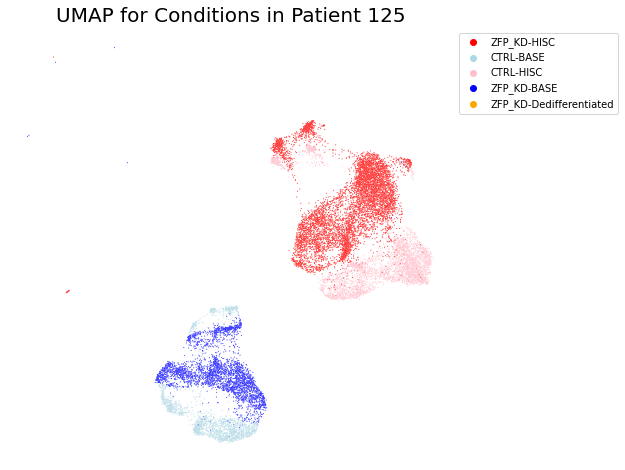

In [63]:
# Define color labels
color_labels = {'CTRL-BASE': 'lightblue', 'CTRL-Dedifferentiated': 'bisque', 'CTRL-HISC': 'pink',
                'ZFP_KD-BASE': 'blue', 'ZFP_KD-Dedifferentiated': 'orange', 'ZFP_KD-HISC': 'red'}

# Filter conditions for Patient 125
ind1 = adata_125.obs.Tumor_Site.isin(['Primary', 'Metastatic'])
ind2 = adata_125.obs.Culture_Media.isin(['BASE', 'Dedifferentiated', 'HISC'])
ind3 = adata_125.obs.ZFP_Expression.isin(['ZFP_KD', 'CTRL'])
ind = ind1 & ind2 & ind3

# Extract UMAP coordinates
umap = adata_125.obsm['X_umap']

# Create a DataFrame for plotting
plot_df = adata_125.obs.loc[ind, ['Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression']]
plot_df['x'] = umap[ind, 0].tolist()
plot_df['y'] = umap[ind, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Scatter plot for conditions not included in 'ind'
plt.scatter(umap[~ind, 0], umap[~ind, 1], color='gainsboro', s=3)

# Scatter plot for conditions in 'ind'
sns.scatterplot(data=plot_df, x='x', y='y', hue='Condition',
                palette=color_labels, ax=ax, legend='full', s=1)

# Set plot aesthetics
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('UMAP for Conditions in Patient 125', fontsize=20)

plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


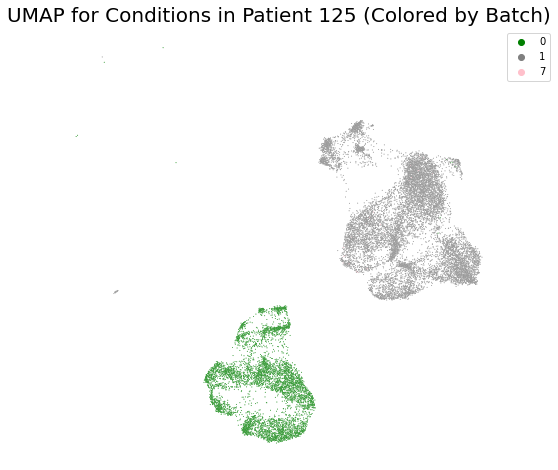

In [58]:
# Define batch color labels
batch_color_labels = {'0': 'green', '1': 'grey', '2': 'red', '3': 'orange', '4': 'blue', '5': 'purple', '6': 'brown', '7': 'pink'}

# Filter conditions for Patient 125
ind1 = adata_125.obs.Tumor_Site.isin(['Primary', 'Metastatic'])
ind2 = adata_125.obs.Culture_Media.isin(['BASE', 'Dedifferentiated', 'HISC'])
ind3 = adata_125.obs.ZFP_Expression.isin(['ZFP_KD', 'CTRL'])
ind = ind1 & ind2 & ind3

# Extract UMAP coordinates
umap = adata_125.obsm['X_umap']

# Create a DataFrame for plotting
plot_df = adata_125.obs.loc[ind, ['Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Batch']]
plot_df['x'] = umap[ind, 0].tolist()
plot_df['y'] = umap[ind, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Scatter plot for conditions not included in 'ind'
plt.scatter(umap[~ind, 0], umap[~ind, 1], color='gainsboro', s=0.1)

# Scatter plot for conditions in 'ind' colored by batch
sns.scatterplot(data=plot_df, x='x', y='y', hue='Batch',
                palette=batch_color_labels, ax=ax, legend='full', s=1)

# Set plot aesthetics
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('UMAP for Conditions in Patient 125 (Colored by Batch)', fontsize=20)

plt.show()


# Subset Patient 146 Data

In [17]:
# Filter the data for Patient 146
adata_146 = adata[adata.obs['Patient'] == 146].copy()

In [18]:
# Check that the Patient 146 data is correct
adata_146.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,log10_original_total_counts,mito_frac,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Replicate,Batch,Sample,phenograph
146P_BASE_shZFP36L2_3_TTAGGGTCAGTAACGG-1,0.028566,0.999801,8876.052734,1.340430,3138,8.051660,9862,9.196546,29.132022,40.701683,...,3.993965,0.048874,146,Primary,BASE,ZFP_KD,1,5,146_P_BASE_ZFPKD_1,5
KG146Li_BASE_shZFP36L2_4_CGTTAGACACGTAACT-1,0.116489,0.999945,9333.853516,0.757079,1427,7.264030,5294,8.574518,68.530412,71.269362,...,3.723784,0.373064,146,Metastatic,BASE,ZFP_KD,2,2,146_M_BASE_ZFPKD_2,14
146P_BASE_shCTRL_AGGTGTTCATACAGGG-1,0.075099,1.000000,8071.062012,0.780837,2078,7.639642,4914,8.500047,35.978836,44.342694,...,3.691435,0.087098,146,Primary,BASE,CTRL,1,5,146_P_BASE_CTRL_1,0
146P_BASE_shZFP36L2_4_CCTCTAGGTCGCATTA-1,0.015017,0.999890,10491.471680,1.244276,4046,8.305731,11282,9.331052,21.680553,30.269456,...,4.052386,0.042723,146,Primary,BASE,ZFP_KD,2,5,146_P_BASE_ZFPKD_2,0
146P_BASE_shZFP36L2_4_CTGTAGACACTCAAGT-1,0.009143,0.999955,12668.316406,1.401741,4815,8.479699,15822,9.669220,25.736317,33.497661,...,4.199261,0.084566,146,Primary,BASE,ZFP_KD,2,5,146_P_BASE_ZFPKD_2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146Li_dedifferentiation_shZFP36L2_4_GCAACATTCTTCTCAA-1,0.061971,0.999989,13519.786133,0.949058,2231,7.710653,10414,9.251002,71.999232,73.862109,...,4.017618,0.166699,146,Metastatic,Dedifferentiated,ZFP_KD,2,4,146_M_Dediff_ZFPKD_2,29
146P_HISC_shZFP36L2_4_ATGAGGGGTCACTGAT-1,0.042308,0.999939,11708.681641,1.083294,3261,8.090096,10390,9.248695,41.308951,50.288739,...,4.016616,0.083157,146,Primary,HISC,ZFP_KD,2,6,146_P_HISC_ZFPKD_2,1
146P_HISC_shZFP36L2_4_ACAAAGATCATCACTT-1,0.021406,0.999804,12408.628906,1.137434,4342,8.376321,11932,9.387063,30.263158,36.188401,...,4.076713,0.100067,146,Primary,HISC,ZFP_KD,2,6,146_P_HISC_ZFPKD_2,13
146P_BASE_shZFP36L2_3_TCAGGTAAGTTTAGGA-1,0.030128,0.999998,8865.494141,1.121671,2957,7.992269,8241,9.016998,31.707317,41.730373,...,3.915980,0.036403,146,Primary,BASE,ZFP_KD,1,5,146_P_BASE_ZFPKD_1,0


In [19]:
# Save the subsetted data
out_dir = '/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/'
os.makedirs(out_dir,exist_ok=True)

adata_146.write_h5ad(out_dir + 'adata.subset146.h5ad')
adata_146.obs.to_csv(out_dir + 'obs.subset146.csv', sep ='\t')

In [59]:
# Load the Patient 146 data
adata_146 = sc.read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.subset146.h5ad")

## Rerun PCA, Clustering, UMAP on Patient 146

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)

    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [22]:
norm_df = pd.DataFrame(adata_146.X, index=adata_146.obs_names, columns = adata_146.var_names)
norm_df = norm_df.loc[:,adata_146.var.highly_variable]

bad_genes = norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
norm_df = norm_df.loc[:,~bad_genes]

In [23]:
'''
PCA
'''
print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))

var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata_146.obsm['X_pca'] = pca_merge.loc[adata_146.obs_names,:].values
adata_146.uns['num_components'] = num_components
adata_146.uns['var_explained'] = var_explained

Performing PCA
# Components = 54
Variance explained = 0.336402


In [24]:
'''
NEAREST NEIGHBORS
'''
print('Performing nearest neighbors')
n_neighbors=30
min_dist = 0.3
sc.pp.neighbors(adata_146, n_neighbors=n_neighbors, n_pcs=pca_merge.shape[1])

Performing nearest neighbors


In [26]:
'''
CLUSTERING
'''
print('Phenograph Clustering')
import phenograph
clusters_merge, _, _ = phenograph.cluster(pca_merge, k=30)
clusters_merge = pd.Series(clusters_merge, pca_merge.index)

adata_146.obs['phenograph'] = clusters_merge.loc[adata_146.obs_names].astype('str').astype('category')

Phenograph Clustering
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 1.6811392307281494 seconds
Jaccard graph constructed in 13.63806700706482 seconds
Wrote graph to binary file in 0.5512516498565674 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.911984
Louvain completed 21 runs in 20.57966685295105 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 43.35989332199097 seconds


In [27]:
'''
UMAP
'''
print('Performing UMAP')
sc.tl.paga(adata_125, groups = 'phenograph')
sc.pl.paga(adata_125, plot=False)
sc.tl.umap(adata_125, init_pos='paga', min_dist=min_dist)

Performing UMAP


## Replot Data for Patient 146

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

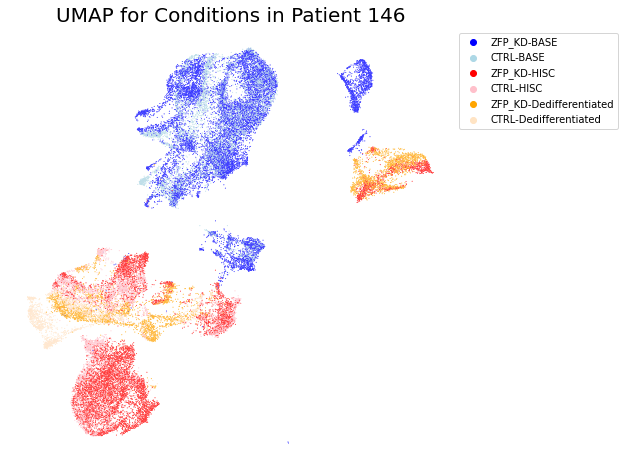

In [62]:
# Define color labels
color_labels = {'CTRL-BASE': 'lightblue', 'CTRL-Dedifferentiated': 'bisque', 'CTRL-HISC': 'pink',
                'ZFP_KD-BASE': 'blue', 'ZFP_KD-Dedifferentiated': 'orange', 'ZFP_KD-HISC': 'red'}
# Filter conditions for Patient 125
ind1 = adata_146.obs.Tumor_Site.isin(['Primary', 'Metastatic'])
ind2 = adata_146.obs.Culture_Media.isin(['BASE', 'Dedifferentiated', 'HISC'])
ind3 = adata_146.obs.ZFP_Expression.isin(['ZFP_KD', 'CTRL'])
ind = ind1 & ind2 & ind3

# Extract UMAP coordinates
umap = adata_146.obsm['X_umap']

# Create a DataFrame for plotting
plot_df = adata_146.obs.loc[ind, ['Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression']]
plot_df['x'] = umap[ind, 0].tolist()
plot_df['y'] = umap[ind, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Scatter plot for conditions not included in 'ind'
plt.scatter(umap[~ind, 0], umap[~ind, 1], color='gainsboro', s=3)

# Scatter plot for conditions in 'ind'
sns.scatterplot(data=plot_df, x='x', y='y', hue='Condition',
                palette=color_labels, ax=ax, legend='full', s=1)

# Set plot aesthetics
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('UMAP for Conditions in Patient 146', fontsize=20)

plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


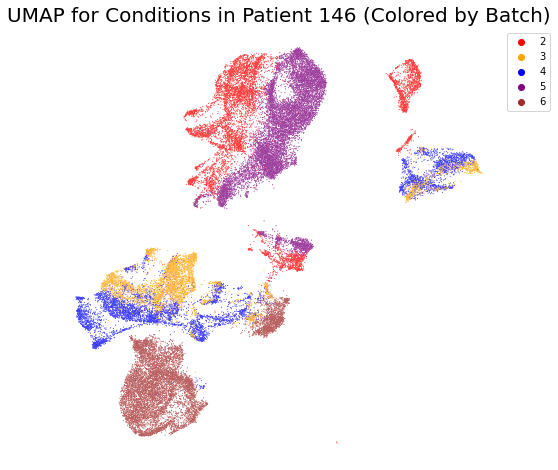

In [61]:
# Define batch color labels
batch_color_labels = {'0': 'green', '1': 'grey', '2': 'red', '3': 'orange', '4': 'blue', '5': 'purple', '6': 'brown', '7': 'pink'}

# Filter conditions for Patient 146
ind1 = adata_146.obs.Tumor_Site.isin(['Primary', 'Metastatic'])
ind2 = adata_146.obs.Culture_Media.isin(['BASE', 'Dedifferentiated', 'HISC'])
ind3 = adata_146.obs.ZFP_Expression.isin(['ZFP_KD', 'CTRL'])
ind = ind1 & ind2 & ind3

# Extract UMAP coordinates
umap = adata_146.obsm['X_umap']

# Create a DataFrame for plotting
plot_df = adata_146.obs.loc[ind, ['Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Batch']]
plot_df['x'] = umap[ind, 0].tolist()
plot_df['y'] = umap[ind, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Scatter plot for conditions not included in 'ind'
plt.scatter(umap[~ind, 0], umap[~ind, 1], color='gainsboro', s=3)

# Scatter plot for conditions in 'ind' colored by batch
sns.scatterplot(data=plot_df, x='x', y='y', hue='Batch',
                palette=batch_color_labels, ax=ax, legend='full', s=1)

# Set plot aesthetics
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('UMAP for Conditions in Patient 146 (Colored by Batch)', fontsize=20)

plt.show()

# UMAPs for Metacells


In [2]:
adata = sc.read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.post.combined.h5ad")

In [5]:
# Look for the ZFP genes in the metacell data
zfp_genes = adata.var[adata.var_names.str.startswith('ZFP')].index.tolist()
zfp_genes

['ZFP1',
 'ZFP14',
 'ZFP2',
 'ZFP28',
 'ZFP3',
 'ZFP30',
 'ZFP36',
 'ZFP36L1',
 'ZFP36L2',
 'ZFP37',
 'ZFP41',
 'ZFP42',
 'ZFP57',
 'ZFP62',
 'ZFP64',
 'ZFP69',
 'ZFP69B',
 'ZFP82',
 'ZFP90',
 'ZFP91',
 'ZFP92',
 'ZFPL1',
 'ZFPM1',
 'ZFPM2',
 'ZFPM2-AS1']

In [15]:
adata.obs

,Patient,Tumor_Site,Culture_Media,ZFP_Expression,Sample_Name,Batch,phenograph
146_P_BASE_ZFPKD_2_SEACell-139,146,Primary,BASE,ZFPKD,146_P_BASE_ZFPKD_2,5,1
146_P_BASE_ZFPKD_1_SEACell-90,146,Primary,BASE,ZFPKD,146_P_BASE_ZFPKD_1,5,11
146_P_HISC_ZFPKD_2_SEACell-82,146,Primary,HISC,ZFPKD,146_P_HISC_ZFPKD_2,6,9
125_P_BASE_ZFPKD_2_SEACell-29,125,Primary,BASE,ZFPKD,125_P_BASE_ZFPKD_2,0,21
146_M_Dediff_ZFPKD_2_SEACell-109,146,Metastatic,Dedifferentiated,ZFPKD,146_M_Dediff_ZFPKD_2,4,12
...,...,...,...,...,...,...,...
146_P_BASE_ZFPKD_2_SEACell-56,146,Primary,BASE,ZFPKD,146_P_BASE_ZFPKD_2,5,8
125_P_BASE_CTRL_1_SEACell-31,125,Primary,BASE,CTRL,125_P_BASE_CTRL_1,0,6
146_P_BASE_CTRL_1_SEACell-88,146,Primary,BASE,CTRL,146_P_BASE_CTRL_1,5,1
125_P_HISC_ZFPKD_1_SEACell-130,125,Primary,HISC,ZFPKD,125_P_HISC_ZFPKD_1,1,4


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

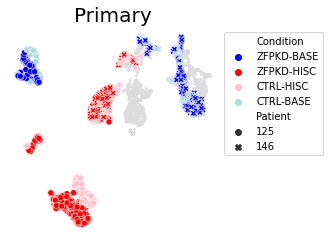

In [66]:
# UMAP for conditions in primary tumor site
color_labels = {}
for col, j in zip(['blue','red','orange'],['BASE','HISC','Dedifferentiated']):
    for shade,i in zip(['light',''],['CTRL','ZFPKD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
        if color_labels[i + '-' + j] =='darkred':
            color_labels[i + '-' + j] = 'orange'
        if color_labels[i + '-' + j] =='lightorange':
            color_labels[i + '-' + j] = 'moccasin'
            
color_labels = {'CTRL-BASE': 'lightblue', 'CTRL-Dedifferentiated': 'bisque', 'CTRL-HISC': 'pink',
                'ZFPKD-BASE': 'blue', 'ZFPKD-Dedifferentiated': 'orange', 'ZFPKD-HISC': 'red'}

fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

ind1 = adata.obs.Tumor_Site=='Primary'
ind2 = adata.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

plt.scatter(plot_df.loc[~ind,'x'], plot_df.loc[~ind,'y'], color='gainsboro', s=3, marker='x')

sns.scatterplot(data=plot_df.loc[ind,:], x='x',y='y', style='Patient', hue='Condition',
                    markers = {'125': 'o', '146': 'X'},
                    palette = color_labels, ax=ax)


ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


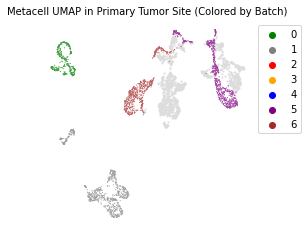

In [83]:
# Define batch color labels
batch_color_labels = {'0': 'green', '1': 'grey', '2': 'red', '3': 'orange', '4': 'blue', '5': 'purple', '6': 'brown', '7': 'pink'}

fig, ax = plt.subplots(1, 1, figsize=(3.8, 3.8))

ind1 = adata.obs.Tumor_Site == 'Primary'
ind2 = adata.obs.Culture_Media != 'Dedifferentiated'
ind = ind1.values & ind2.values

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:, ['Culture_Media', 'ZFP_Expression', 'Batch']]
plot_df['x'] = umap[:, 0].tolist()
plot_df['y'] = umap[:, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

plt.scatter(plot_df.loc[~ind, 'x'], plot_df.loc[~ind, 'y'], color='gainsboro', s=1)

sns.scatterplot(data=plot_df.loc[ind, :], x='x', y='y', hue='Batch',
                palette=batch_color_labels, ax=ax, s=1)

ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('Metacell UMAP in Primary Tumor Site (Colored by Batch)', fontsize=10)

plt.show()

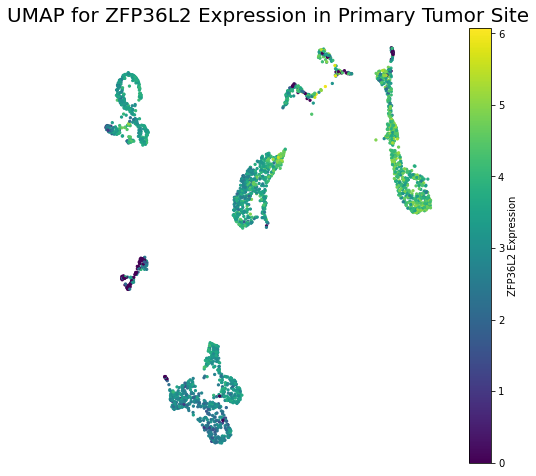

In [24]:
# Extract ZFP36L2 expression
zfp36l2_expression = adata[:, adata.var_names == 'ZFP36L2'].X.toarray().flatten()

# Create a DataFrame for plotting
plot_df_zfp36l2 = adata.obs.loc[:, ['Patient', 'Culture_Media', 'ZFP_Expression']]
plot_df_zfp36l2['x'] = umap[:, 0].tolist()
plot_df_zfp36l2['y'] = umap[:, 1].tolist()
plot_df_zfp36l2['Condition'] = plot_df_zfp36l2['ZFP_Expression'].astype(str) + '-' + plot_df_zfp36l2['Culture_Media'].astype(str)
plot_df_zfp36l2['ZFP36L2_Expression'] = zfp36l2_expression

# Create the UMAP plot with heatmap-like color
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Scatter plot with heatmap-like color based on ZFP36L2 expression
scatter = plt.scatter(plot_df_zfp36l2.loc[ind, 'x'], plot_df_zfp36l2.loc[ind, 'y'], c=plot_df_zfp36l2.loc[ind, 'ZFP36L2_Expression'], cmap='viridis', s=5)

# Set plot aesthetics
ax.set_axis_off()
ax.set_title('UMAP for ZFP36L2 Expression in Primary Tumor Site', fontsize=20)

# Add a color bar
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical')
cbar.set_label('ZFP36L2 Expression')

plt.show()


/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Metastasis in Patient 146')

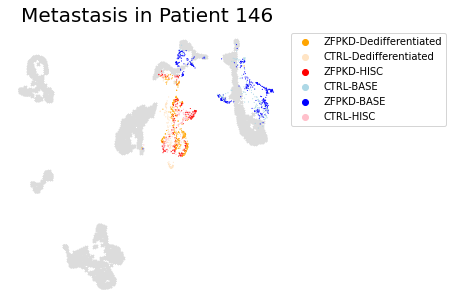

In [67]:
# UMAP for conditions in the metastatic tumor site
fig, ax=plt.subplots(1,1, figsize=(5,5))

ind = adata.obs.Tumor_Site=='Metastatic'

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:,['Patient','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

plt.scatter(plot_df.loc[~ind,'x'], plot_df.loc[~ind,'y'], color='gainsboro', s=10, marker='x')

g = sns.scatterplot(data=plot_df.loc[ind,:], x='x',y='y', hue='Condition',
                    s=1,edgecolor=None,
                    palette = color_labels, ax=ax)
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Metastasis in Patient 146',fontsize=20)

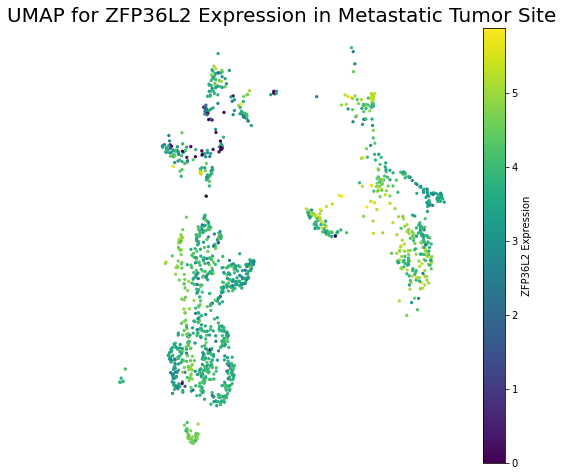

In [27]:
# Extract ZFP36L2 expression
zfp36l2_expression = adata[:, adata.var_names == 'ZFP36L2'].X.toarray().flatten()

# Create a DataFrame for plotting
plot_df_zfp36l2 = adata.obs.loc[:, ['Patient', 'Culture_Media', 'ZFP_Expression']]
plot_df_zfp36l2['x'] = umap[:, 0].tolist()
plot_df_zfp36l2['y'] = umap[:, 1].tolist()
plot_df_zfp36l2['Condition'] = plot_df_zfp36l2['ZFP_Expression'].astype(str) + '-' + plot_df_zfp36l2['Culture_Media'].astype(str)
plot_df_zfp36l2['ZFP36L2_Expression'] = zfp36l2_expression

# Create the UMAP plot with heatmap-like color
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Scatter plot with heatmap-like color based on ZFP36L2 expression
scatter = plt.scatter(plot_df_zfp36l2.loc[ind, 'x'], plot_df_zfp36l2.loc[ind, 'y'], c=plot_df_zfp36l2.loc[ind, 'ZFP36L2_Expression'], cmap='viridis', s=5)

# Set plot aesthetics
ax.set_axis_off()
ax.set_title('UMAP for ZFP36L2 Expression in Metastatic Tumor Site', fontsize=20)

# Add a color bar
cbar = plt.colorbar(scatter, ax=ax, orientation='vertical')
cbar.set_label('ZFP36L2 Expression')

plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


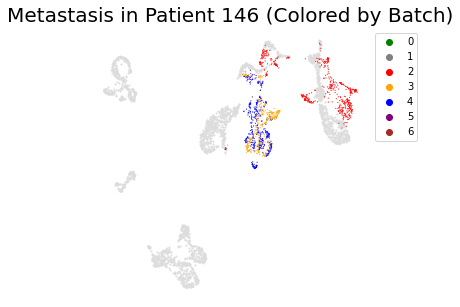

In [85]:
# Define batch color labels
batch_color_labels = {'0': 'green', '1': 'grey', '2': 'red', '3': 'orange', '4': 'blue', '5': 'purple', '6': 'brown', '7': 'pink'}

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

ind = adata.obs.Tumor_Site == 'Metastatic'

umap = adata.obsm['X_umap']
plot_df = adata.obs.loc[:, ['Culture_Media', 'ZFP_Expression', 'Batch']]
plot_df['x'] = umap[:, 0].tolist()
plot_df['y'] = umap[:, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

plt.scatter(plot_df.loc[~ind, 'x'], plot_df.loc[~ind, 'y'], color='gainsboro', s=1)

sns.scatterplot(data=plot_df.loc[ind, :], x='x', y='y', hue='Batch',
                palette=batch_color_labels, ax=ax, s=1, edgecolor=None)

ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('Metastasis in Patient 146 (Colored by Batch)', fontsize=20)

plt.show()

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=Fals

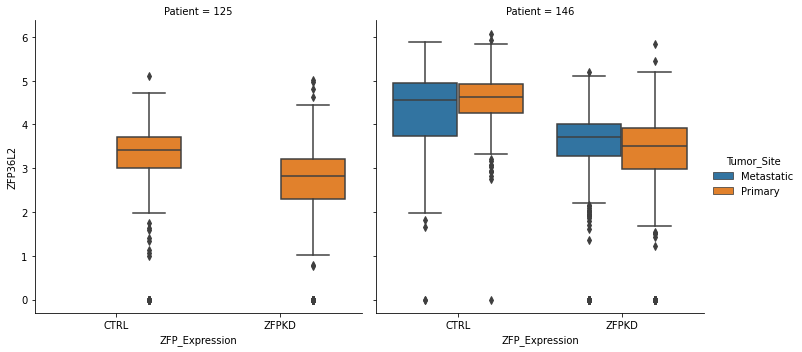

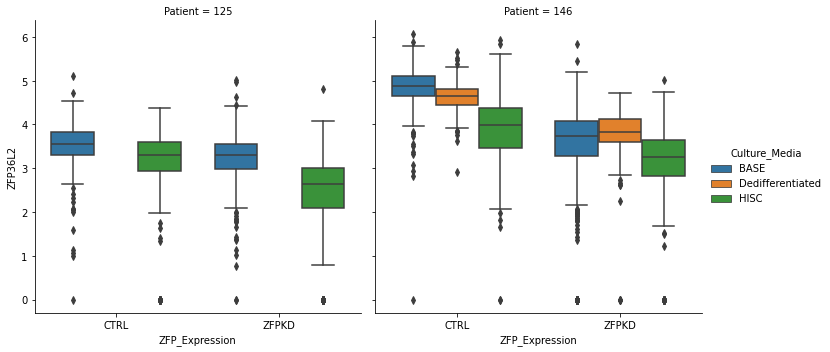

In [46]:
plot_df = adata.obs
plot_df.loc[:,'ZFP36L2'] = adata.X[:,adata.var_names=='ZFP36L2']
sns.catplot(data=plot_df, x='ZFP_Expression', y='ZFP36L2', hue='Tumor_Site', col='Patient', kind='box') 
sns.catplot(data=plot_df, x='ZFP_Expression', y='ZFP36L2', hue='Culture_Media', col='Patient', kind='box')

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=Fals

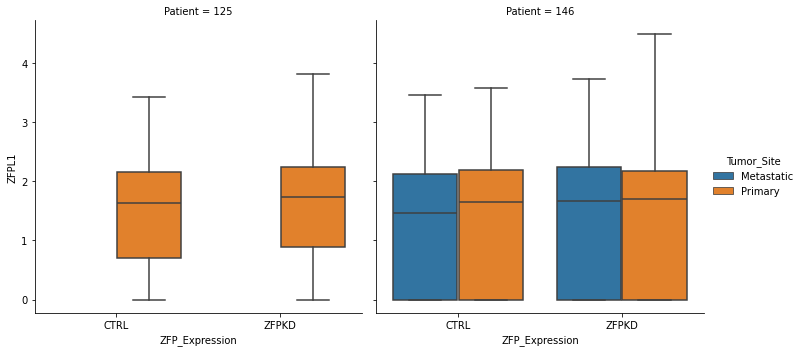

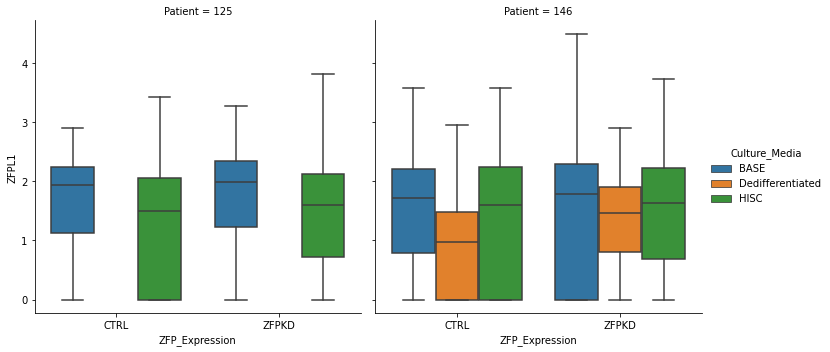

In [45]:
plot_df = adata.obs
plot_df.loc[:,'ZFPL1'] = adata.X[:,adata.var_names=='ZFPL1']
sns.catplot(data=plot_df, x='ZFP_Expression', y='ZFPL1', hue='Tumor_Site', col='Patient', kind='box')
sns.catplot(data=plot_df, x='ZFP_Expression', y='ZFPL1', hue='Culture_Media', col='Patient', kind='box')

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=Fals

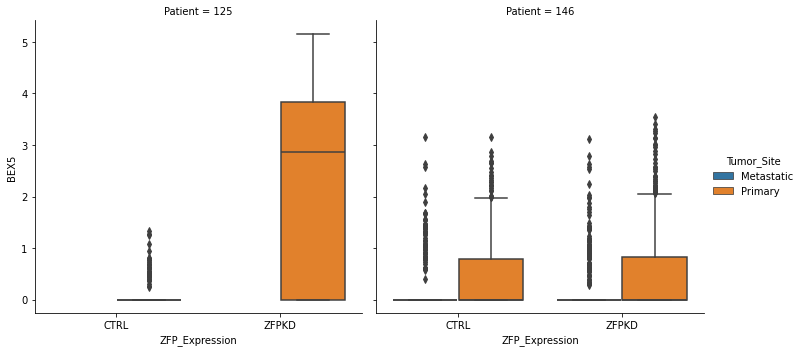

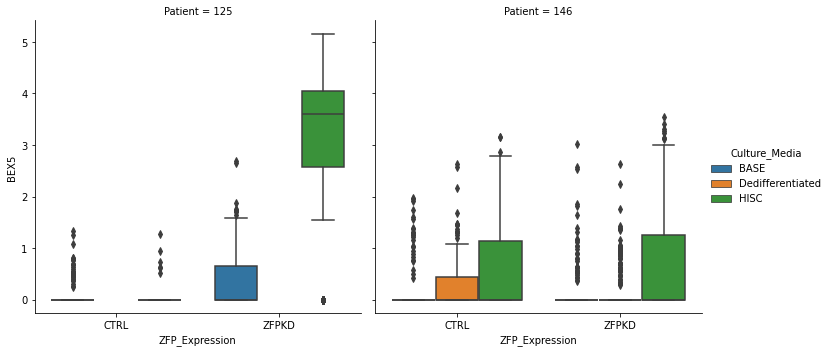

In [3]:
plot_df = adata.obs
plot_df.loc[:,'BEX5'] = adata.X[:,adata.var_names=='BEX5']
sns.catplot(data=plot_df, x='ZFP_Expression', y='BEX5', hue='Tumor_Site', col='Patient', kind='box')
sns.catplot(data=plot_df, x='ZFP_Expression', y='BEX5', hue='Culture_Media', col='Patient', kind='box')

In [68]:
# Convert 'Patient' to integer
adata.obs['Patient'] = adata.obs['Patient'].astype(int)
# Filter the data for Patient 125
adata_meta_125 = adata[adata.obs['Patient'] == 125].copy()

In [69]:
adata_meta_125

AnnData object with n_obs × n_vars = 1201 × 32485
    obs: 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch', 'phenograph'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'umap', 'var_explained'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'raw', 'without_log'
    obsp: 'connectivities', 'distances'

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

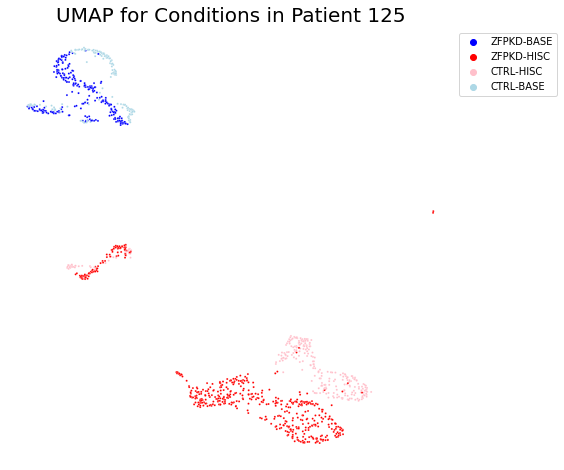

In [75]:
%matplotlib inline
# Define color labels
color_labels = {'CTRL-BASE': 'lightblue', 'CTRL-Dedifferentiated': 'bisque', 'CTRL-HISC': 'pink',
                'ZFPKD-BASE': 'blue', 'ZFPKD-Dedifferentiated': 'orange', 'ZFPKD-HISC': 'red'}

# Filter conditions for Patient 125
ind1 = adata_meta_125.obs.Tumor_Site.isin(['Primary', 'Metastatic'])
ind2 = adata_meta_125.obs.Culture_Media.isin(['BASE', 'Dedifferentiated', 'HISC'])
ind3 = adata_meta_125.obs.ZFP_Expression.isin(['ZFPKD', 'CTRL'])
ind = ind1 & ind2 & ind3

# Extract UMAP coordinates
umap = adata_meta_125.obsm['X_umap']

# Create a DataFrame for plotting
plot_df = adata_meta_125.obs.loc[ind, ['Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression']]
plot_df['x'] = umap[ind, 0].tolist()
plot_df['y'] = umap[ind, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Scatter plot for conditions not included in 'ind'
plt.scatter(umap[~ind, 0], umap[~ind, 1], color='gainsboro', s=3)

# Scatter plot for conditions in 'ind'
sns.scatterplot(data=plot_df, x='x', y='y', hue='Condition',
                palette=color_labels, ax=ax, legend='full', s=4)

# Set plot aesthetics
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('UMAP for Conditions in Patient 125', fontsize=20)

plt.show()

In [76]:
# Convert 'Patient' to integer
adata.obs['Patient'] = adata.obs['Patient'].astype(int)
# Filter the data for Patient 146
adata_meta_146 = adata[adata.obs['Patient'] == 146].copy()

In [77]:
adata_meta_146

AnnData object with n_obs × n_vars = 2733 × 32485
    obs: 'Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression', 'Sample_Name', 'Batch', 'phenograph'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'log1p', 'neighbors', 'num_components', 'paga', 'phenograph_sizes', 'umap', 'var_explained'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts', 'raw', 'without_log'
    obsp: 'connectivities', 'distances'

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

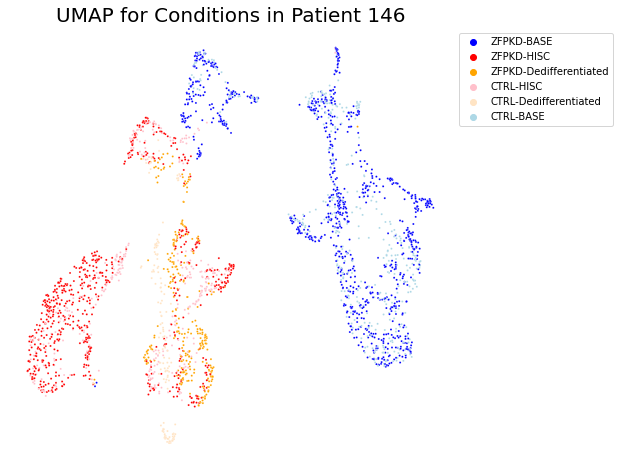

In [78]:
# Define color labels
color_labels = {'CTRL-BASE': 'lightblue', 'CTRL-Dedifferentiated': 'bisque', 'CTRL-HISC': 'pink',
                'ZFPKD-BASE': 'blue', 'ZFPKD-Dedifferentiated': 'orange', 'ZFPKD-HISC': 'red'}
# Filter conditions for Patient 125
ind1 = adata_meta_146.obs.Tumor_Site.isin(['Primary', 'Metastatic'])
ind2 = adata_meta_146.obs.Culture_Media.isin(['BASE', 'Dedifferentiated', 'HISC'])
ind3 = adata_meta_146.obs.ZFP_Expression.isin(['ZFPKD', 'CTRL'])
ind = ind1 & ind2 & ind3

# Extract UMAP coordinates
umap = adata_meta_146.obsm['X_umap']

# Create a DataFrame for plotting
plot_df = adata_meta_146.obs.loc[ind, ['Patient', 'Tumor_Site', 'Culture_Media', 'ZFP_Expression']]
plot_df['x'] = umap[ind, 0].tolist()
plot_df['y'] = umap[ind, 1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Scatter plot for conditions not included in 'ind'
plt.scatter(umap[~ind, 0], umap[~ind, 1], color='gainsboro', s=3)

# Scatter plot for conditions in 'ind'
sns.scatterplot(data=plot_df, x='x', y='y', hue='Condition',
                palette=color_labels, ax=ax, legend='full', s=4)

# Set plot aesthetics
ax.set_axis_off()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('UMAP for Conditions in Patient 146', fontsize=20)

plt.show()

In [10]:
# Filter the data for Patient 146
adata_meta_146 = adata[adata.obs['Patient'] == 146].copy()

/home/forsythb/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


## Run HVGs, PCA, Clustering, UMAP on Metacell Data

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

import numpy.matlib
def kneepoint(vec):
    curve =  [1-x for x in vec]
    nPoints = len(curve)
    allCoord = np.vstack((range(nPoints), curve)).T
    np.array([range(nPoints), curve])
    firstPoint = allCoord[0]
    lineVec = allCoord[-1] - allCoord[0]
    lineVecNorm = lineVec / np.sqrt(np.sum(lineVec**2))
    vecFromFirst = allCoord - firstPoint
    scalarProduct = np.sum(vecFromFirst * numpy.matlib.repmat(lineVecNorm, nPoints, 1), axis=1)
    vecFromFirstParallel = np.outer(scalarProduct, lineVecNorm)
    vecToLine = vecFromFirst - vecFromFirstParallel
    distToLine = np.sqrt(np.sum(vecToLine ** 2, axis=1))
    idxOfBestPoint = np.argmax(distToLine)
    return idxOfBestPoint

def RunPCA(cts, var_threshold, n_components=300):
    pca = PCA(n_components=n_components, svd_solver='randomized')
    pca.fit(cts)

    num_components = 0
    num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
    num_components = max(num_components,np.where(np.cumsum(pca.explained_variance_ratio_) > var_threshold)[0][0])
    var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
    print('# Components = %d' % (num_components+1))
    print('Variance explained = %f' % var_explained)
    return pca, num_components, var_explained

In [ ]:
norm_df = pd.DataFrame(adata, index=adata.obs_names, columns = adata.var_names)

In [40]:
norm_df = pd.DataFrame(adata, index=adata.obs_names, columns = adata.var_names)
#norm_df = norm_df.loc[:,adata.var.highly_variable]

bad_genes = norm_df.columns.str.contains(
    "^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|MALAT")
norm_df = norm_df.loc[:,~bad_genes]

KeyboardInterrupt: 

In [ ]:
'''
PCA
'''
print('Performing PCA')
n_components=500
pca = PCA(n_components=n_components, svd_solver='randomized')
pca.fit(norm_df)

#By Kneepoint
num_components = 0
num_components = max(num_components,kneepoint(np.cumsum(pca.explained_variance_ratio_)))
print('# Components = %d' % (num_components+1))

var_explained = np.cumsum(pca.explained_variance_ratio_)[num_components]
print('Variance explained = %f' % var_explained)

pca = PCA(n_components=num_components, svd_solver='randomized')
pca_merge = pd.DataFrame(pca.fit_transform(norm_df.values),
                index=norm_df.index)
adata_146.obsm['X_pca'] = pca_merge.loc[adata_146.obs_names,:].values
adata_146.uns['num_components'] = num_components
adata_146.uns['var_explained'] = var_explained

 # Extract the Count Matrix for DESeq2

In [ ]:
# Read in the adata from metacells
adata_meta = sc.read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/adata.post.combined.h5ad")

In [ ]:
t=adata.raw.X.toarray()
pd.DataFrame(data=t, index=adata.obs_names, columns=adata.raw.var_names).to_csv('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/metacells_count_matrix.csv')
pd.DataFrame(adata.obs).to_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/metacells_noscvi/metacell_metadata.csv")

In [36]:
# Extract the count matrix from metacells
count_matrix = adata_meta.X
count_matrix.shape

(3934, 32485)

In [44]:
# Convert the count matrix to a Pandas DataFrame
count_matrix_df = pd.DataFrame(count_matrix, index=adata_meta.obs_names, columns=adata_meta.var_names)
count_matrix_df

gene_name,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A3GALT2,A4GALT,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
146_P_BASE_ZFPKD_2_SEACell-139,0.0,0.0,3.918949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.155918,2.245804,4.166389,0.000000,0.292571,2.723747,0.000000,2.622887,0.979258,1.938760
146_P_BASE_ZFPKD_1_SEACell-90,0.0,0.0,4.333043,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.980986,0.000000,0.000000,0.000000,1.517427,3.099643,0.000000,2.983210,0.000000,1.974598
146_P_HISC_ZFPKD_2_SEACell-82,0.0,0.0,3.714498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.959946,0.000000,0.000000,0.000000,0.666979,2.567582,0.666979,3.691243,0.000000,1.998722
125_P_BASE_ZFPKD_2_SEACell-29,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.444900,0.000000,2.668407,0.000000,3.861263
146_M_Dediff_ZFPKD_2_SEACell-109,0.0,0.0,2.204153,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.809415,3.375857,3.466371,0.000000,0.000000,2.900476,0.000000,3.370308,0.000000,3.172397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146_P_BASE_ZFPKD_2_SEACell-56,0.0,0.0,3.503150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.773155,0.000000,3.257539,2.257043,0.000000
125_P_BASE_CTRL_1_SEACell-31,0.0,0.0,2.074565,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.175778,1.620006,0.779657,0.000000,0.551792,2.741843,0.000000,2.934362,2.915431,2.833673
146_P_BASE_CTRL_1_SEACell-88,0.0,0.0,3.501356,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.163021,2.688052,3.284443,0.474203,0.000000,2.654666,0.725133,2.876298,0.000000,1.876704
125_P_HISC_ZFPKD_1_SEACell-130,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,1.083524,1.798705,0.000000,0.000000,2.905217,0.000000,2.266697,1.664531,1.926295


In [46]:
# Save the count matrix as a CSV file
count_matrix_df.to_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/metacells_count_matrix.csv")

In [ ]:
# Read in the adata from the single cell data
adata_sc = sc.read_h5ad("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/adata.combined.hvg_5000.h5ad")

In [ ]:
# Extract the count matrix from metacells
count_matrix = adata_meta.X
count_matrix.shape

In [ ]:
# Convert the count matrix to a Pandas DataFrame
count_matrix_df = pd.DataFrame(count_matrix, index=adata_meta.obs_names, columns=adata_meta.var_names)
count_matrix_df

In [ ]:
# Save the count matrix as a CSV file
count_matrix_df.to_csv("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output/combined/out_post_hvg/metacells_count_matrix.csv")

/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/forsythb/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) inst

Text(0.5, 1.0, 'Primary')

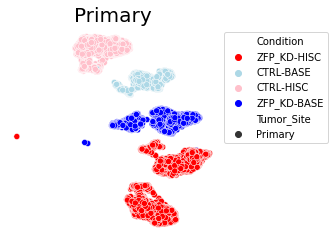

In [35]:
# UMAP for conditions in primary tumor site
color_labels = {}
for col, j in zip(['blue','red','orange'],['BASE','HISC','Dedifferentiated']):
    for shade,i in zip(['light',''],['CTRL','ZFP_KD']):
        color_labels[i + '-' + j] = shade + col
        if color_labels[i + '-' + j] =='lightred':
            color_labels[i + '-' + j] = 'pink'
        if color_labels[i + '-' + j] =='darkred':
            color_labels[i + '-' + j] = 'orange'
        if color_labels[i + '-' + j] =='lightorange':
            color_labels[i + '-' + j] = 'moccasin'


fig, ax=plt.subplots(1,1, figsize=(3.8,3.8))

ind1 = adata_125.obs.Tumor_Site=='Primary'
ind2 = adata_125.obs.Culture_Media!='Dedifferentiated'
ind = ind1.values & ind2.values

umap = adata_125.obsm['X_umap']
plot_df = adata_125.obs.loc[:,['Tumor_Site','Culture_Media','ZFP_Expression']]
plot_df['x'] = umap[:,0].tolist()
plot_df['y'] = umap[:,1].tolist()
plot_df['Condition'] = plot_df.ZFP_Expression.astype(str) + '-' + plot_df.Culture_Media.astype(str)

plt.scatter(plot_df.loc[~ind,'x'], plot_df.loc[~ind,'y'], color='gainsboro', s=3, marker='x')

sns.scatterplot(data=plot_df.loc[ind,:], x='x',y='y', style='Tumor_Site', hue='Condition',
                    markers = {'Primary': 'o', 'Metastatic': 'X'},
                    palette = color_labels, ax=ax)


ax.set_axis_off()
ax.legend(bbox_to_anchor=(1,1), loc='upper left')
ax.set_title('Primary',fontsize=20)